# Getting started with Python and Jupyter

**Read this one first, and run every cell as you go.**

This notebook assumes you have written Python before — variables, `print`, functions,
lists, dictionaries, `for` loops — and that you have *not* used the scientific libraries
the rest of these notebooks are built on. Those are the only genuinely new things here:

- **NumPy**, for arrays of numbers that do arithmetic,
- **Matplotlib**, for plots.

There is nothing to install. Open this notebook from the book's website and it runs in a
browser tab, or clone the repository and run `uv run jupyter lab`.

The only thermodynamics used below is the ideal gas law from §1.6,

$$P\underline{V} = RT \qquad\text{so}\qquad \underline{V} = \frac{RT}{P},$$

where $\underline{V}$ is the **molar** volume (the underbar means *per mole*). Everything
else is Python.

## 1. A notebook is a list of cells

There are two kinds of cell. **Markdown cells** hold text like this one — double-click
this cell to see the plain text behind it, then press `Shift+Enter` to set it back.
**Code cells** hold Python.

To run a cell, click in it and press `Shift+Enter`. Run the next one now.

In [1]:
# This is a code cell. Click in it and press Shift+Enter.

R = 8.314      # J/(mol K), the gas constant
T = 300.0      # K
P = 1.0e5      # Pa  (1 bar = 10^5 Pa)

V = R * T / P  # molar volume, m^3/mol
print(V)

0.024942


Two things just happened.

**The `[ ]` to the left of the cell became `[1]`.** That number counts the cells you have
run, in the order you ran them. It is not the cell's position on the page — and that
matters more than it sounds, because a notebook remembers whatever you last ran, not what
is written above. If you edit a cell near the top and do not re-run it, everything below
is still using the old value.

> **The habit that saves you:** before you hand anything in, use
> **Kernel → Restart Kernel and Run All Cells**. If the notebook works from a clean start,
> top to bottom, it works. If it does not, you have found a real bug rather than a
> grading surprise.

**Second, a cell displays its last expression even without `print`.**

In [2]:
V   # no print(), but the value still appears

0.024942

## 2. What you already know still works

Your first programming course covered everything in the next cell. Nothing about it
changes here. Read it to confirm that, then move on — the new material starts in §3.

In [3]:
def molar_volume(T, P):
    """Ideal-gas molar volume in m^3/mol.  T in K, P in Pa."""
    return R * T / P


temperatures = [200.0, 300.0, 400.0]          # a list

for Ti in temperatures:                        # a for loop
    print(f"T = {Ti:5.0f} K   V = {molar_volume(Ti, 1.0e5):.5f} m^3/mol")

gas = {"name": "carbon dioxide", "Tc": 304.1, "Pc": 73.8}     # a dictionary
print(f"\n{gas['name']}: Tc = {gas['Tc']} K, Pc = {gas['Pc']} bar")

T =   200 K   V = 0.01663 m^3/mol
T =   300 K   V = 0.02494 m^3/mol
T =   400 K   V = 0.03326 m^3/mol

carbon dioxide: Tc = 304.1 K, Pc = 73.8 bar


## 3. Why a list is not enough

A list *holds* numbers. It does not do arithmetic with them. This is the one thing from
your first course that will not carry you through this book. Watch it fail.

In [4]:
temperatures = [200.0, 300.0, 400.0]

print(temperatures * 2)        # NOT 400, 600, 800 -- the list is repeated instead
# print(temperatures / 100)    # uncomment this line: TypeError, lists cannot divide

[200.0, 300.0, 400.0, 200.0, 300.0, 400.0]


## 4. NumPy: arrays that do arithmetic

A NumPy **array** looks like a list and behaves like a number. Arithmetic on it happens
**element by element**, which is what you wanted above.

By convention NumPy is imported as `np`. You will see that abbreviation in every notebook
in this book and in essentially every Python program that touches numbers.

In [5]:
import numpy as np

T = np.array([200.0, 300.0, 400.0])     # an array, not a list

print(T * 2)                # 400 600 800
print(T - 273.15)           # the same temperatures in degrees Celsius
print(R * T / 1.0e5)        # the molar volume at all three temperatures at once

[400. 600. 800.]
[-73.15  26.85 126.85]
[0.016628 0.024942 0.033256]


You will rarely type an array out by hand. Two functions build them for you:

- `np.linspace(start, stop, n)` — `n` evenly spaced points, **including** `stop`;
- `np.arange(start, stop, step)` — steps of a fixed size, **excluding** `stop`.

The next cell also makes the most important point in this notebook: a function you wrote
for a single number usually works on a whole array without any change, because it only
uses `*`, `/`, `+`, `-`. The `for` loop and the one-line version give identical answers.

In [6]:
T_grid = np.linspace(200.0, 500.0, 7)      # 7 points, 200 to 500 inclusive
print(T_grid)
print(np.arange(200.0, 501.0, 50.0))       # note the 501: arange stops BEFORE its limit

# The loop you would have written in your first course...
V_loop = []
for Ti in T_grid:
    V_loop.append(molar_volume(Ti, 1.0e5))
V_loop = np.array(V_loop)

# ...and the line that replaces it. Same function, handed the whole array.
V_array = molar_volume(T_grid, 1.0e5)

print(np.allclose(V_loop, V_array))        # True: the two agree to roundoff

[200. 250. 300. 350. 400. 450. 500.]
[200. 250. 300. 350. 400. 450. 500.]
True


`np.allclose(a, b)` asks whether two arrays agree to within roundoff. Use it, not `==`,
whenever you compare computed numbers — two calculations of the same quantity in floating
point are almost never *exactly* equal.

Arrays are indexed and sliced like lists, and they carry their own summary functions.

In [7]:
print(T_grid[0], T_grid[-1])           # first and last
print(T_grid[:3])                      # the first three
print(T_grid.min(), T_grid.max(), T_grid.mean())
print(len(T_grid), T_grid.shape)       # how many, and how they are arranged

200.0 500.0
[200. 250. 300.]
200.0 500.0 350.0
7 (7,)


## 5. Matplotlib: the same four steps every time

Every plot in this book is built the same way. Learn this pattern once:

1. `fig, ax = plt.subplots()` — make a figure (`fig`) with one set of axes (`ax`);
2. `ax.plot(x, y)` — draw, once per curve;
3. `ax.set_xlabel(...)` / `ax.set_ylabel(...)` — **always label both axes, with units**;
4. `ax.legend()` — if there is more than one curve.

An unlabeled axis is a wrong answer, in this course and afterwards.

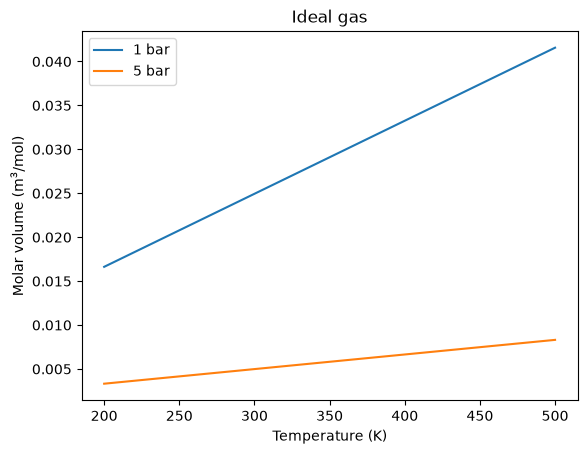

In [8]:
import matplotlib.pyplot as plt

T_grid = np.linspace(200.0, 500.0, 100)

fig, ax = plt.subplots()
ax.plot(T_grid, molar_volume(T_grid, 1.0e5), label="1 bar")
ax.plot(T_grid, molar_volume(T_grid, 5.0e5), label="5 bar")
ax.set_xlabel("Temperature (K)")
ax.set_ylabel("Molar volume (m$^3$/mol)")
ax.set_title("Ideal gas")
ax.legend()
plt.show()

Two details to take from this. The dollar signs in `"m$^3$/mol"` switch on mathematical
typesetting, so you can write real superscripts, subscripts and Greek letters in a label.
And `plt.show()` at the end keeps the notebook from printing the figure's internal
representation above the picture.

## 6. Printing a table you can actually read

`print` on its own gives you unaligned columns. An f-string with a width and a number of
decimal places — `{value:8.3f}` means *8 characters wide, 3 decimal places* — gives you a
table. `>8` right-aligns a heading in 8 characters.

In [9]:
print(f"{'T (K)':>8}{'V, 1 bar':>14}{'V, 5 bar':>14}")
for Ti in np.linspace(200.0, 500.0, 7):
    print(f"{Ti:8.0f}{molar_volume(Ti, 1.0e5):14.5f}{molar_volume(Ti, 5.0e5):14.5f}")

   T (K)      V, 1 bar      V, 5 bar
     200       0.01663       0.00333
     250       0.02079       0.00416
     300       0.02494       0.00499
     350       0.02910       0.00582
     400       0.03326       0.00665
     450       0.03741       0.00748
     500       0.04157       0.00831


## 7. Four things that will go wrong

**1. You will run cells out of order.** The symptom is a `NameError` for something you can
see defined further up the page, or — worse, because it does not complain — an answer
computed from a value you have since changed. Restart and Run All.

**2. Units.** Python does not know that `P` is a pressure. If you hand `molar_volume` a
pressure in bar instead of pascals, you get a number that is wrong by a factor of
$10^{5}$, with no error message at all.

In [10]:
P_bar = 1.0                                       # "one bar"

print(molar_volume(300.0, P_bar))                 # 2494 m^3/mol -- absurd, but no error
print(molar_volume(300.0, P_bar * 1.0e5))         # 0.0249 m^3/mol -- correct

# Every notebook in this book works in SI: K, Pa, m^3, J, mol. Convert on the way in.

2494.2
0.024942


**3. You will use a list where an array belongs.** If arithmetic gives you a repeated list
or a `TypeError`, wrap it: `np.array(my_list)`.

**4. Read the *last* line of an error message first.** Python prints the chain of calls
that led to the failure, which is long and mostly irrelevant. The last line names the
error, and usually nothing above it is needed.

One more thing you will meet: some later notebooks open with a short cell labeled
*Colab bootstrap*. It downloads the book's data files when they are not already beside the
notebook, and does nothing at all when they are. You never need to edit it.

## What this notebook shows

- A notebook remembers what you **ran**, not what is **written**. `Restart Kernel and Run
  All Cells` is the only way to be sure of your own results.
- Lists hold numbers; **NumPy arrays calculate with them.** `np.linspace` and `np.arange`
  build them, and a function written for one number usually works on an array unchanged.
- Every plot is the same four steps, and both axes always carry units.
- Python tracks numbers, not units. **Keeping everything in SI is not tidiness, it is the
  only defense you have** — the wrong-units answer above raised no error whatsoever.

## Your turn

1. Change the two pressures in the plot in §5 to 1 bar and 10 bar. Before you run it,
   predict whether the 10 bar curve moves up or down.
2. Add a third curve at 20 bar, with its own legend entry.
3. Make the table in §6 print molar volume in **liters** per mole rather than
   m$^3$/mol, with the heading changed to match. (1 m$^3$ = 1000 L.)
4. At what temperature does an ideal gas at 1 bar occupy exactly 0.0300 m$^3$/mol? Get
   the answer two ways — by rearranging the equation, and by finding it on your plot —
   and check that they agree.